In [1]:
from functools import partial
import jax
from jax import random
from jax import numpy as jnp
from matplotlib.pyplot import hist
import time


@partial(jax.jit, static_argnums=(1,))
def mh_kernel(rng_key, prob_fn, prob_params, position, prob, step_size, PBC=10.0):
    key1, key2 = random.split(rng_key)
    proposal = position + random.uniform(
        key1, shape=position.shape, minval=-step_size, maxval=step_size
    )
    proposal = ((proposal + 0.5 * PBC) % PBC) - 0.5 * PBC
    proposal_prob = prob_fn(proposal, prob_params)
    accept_prob = jnp.minimum(1.0, proposal_prob / prob)
    accept = jax.random.uniform(key2) < accept_prob
    new_position = jnp.where(accept, proposal, position)
    new_prob = jnp.where(accept, proposal_prob, prob)
    acceptance_rate = jnp.mean(accept.astype(jnp.float32))
    return new_position, new_prob, acceptance_rate


@jax.jit
def adapt_step_size(step_size, accept, target=0.5, lr=0.01):
    # accept is a float 0.0 or 1.0
    # return step_size * jnp.exp(lr * (accept - target))
    return step_size


@partial(jax.jit, static_argnums=(1, 2, 3))
def mh_chain(rng_key, n_steps, PBC, prob_fn, prob_params, init_position, step_size=1.0):
    """MH single chain.

    If this chain is executed alone, then you obtain 1 single sample taken after n_steps.

    To obtain multiple samples, run multiple chains in parallel:

    sampler = jax.vmap(mh_chain, in_axes=(0, None, None, None, None, 0), out_axes=0)

    That means:
    - in_axes:
        - 0: different rng_key per chain
        - None: same n_steps for all chains
        - None: same PBC for all chains
        - None: same prob_fn for all chains
        - None: same prob_params per chain
        - 0: different init_position per chain
        - None: same step_size per chain

    INPUTS: 
    - rng_key: jax.random.PRNGKey
    - n_steps: int, number of MH steps to perform
    - PBC: float, periodic boundary conditions box size
    - prob_fn: function(position, prob_params) -> probability density at position
    - prob_params: parameters for prob_fn
    - init_position: jnp.array of shape (n_dim,), initial position of the chain
    - step_size: float, initial step size for proposals
    RETURNS:
    - positions: jnp.array of shape (n_steps, n_dim), sampled positions along the chain

    """

    def body_fn(val, _):
        key, position, prob, step_size = val
        key, subkey = random.split(key)
        new_position, new_prob, acceptance_rate = mh_kernel(
            subkey, prob_fn, prob_params, position, prob, step_size=step_size, PBC=PBC
        )
        step_size = adapt_step_size(step_size, acceptance_rate)
        _carry = (key, new_position, new_prob, step_size)
        return _carry, new_position

    init_prob = prob_fn(init_position, prob_params)
    init_val = (rng_key, init_position, init_prob, step_size)
    _, positions = jax.lax.scan(body_fn, init_val, None, length=n_steps)
    return positions


In [2]:
print("This is the qvarnet.sampler module.")
print("TESTING PLAYGROUND FOR THE SAMPLER MODULE")

key = random.PRNGKey(0)

def test_prob_fn(x, params):
    return jnp.exp(-0.5 * jnp.sum((x) ** 2, axis=-1))

sampler = jax.vmap(mh_chain, in_axes=(0, None, None, None, 0, 0), out_axes=0)
n_chains = 1
DoF = 1
n_steps = 10000
PBC = 20
print("CONFIG USED:")
print(f"n_chains: {n_chains}, DoF: {DoF}, n_steps: {n_steps}")
rng_keys = random.split(random.PRNGKey(872643), n_chains)
init_positions = jax.random.normal(random.PRNGKey(0), (n_chains, DoF)) * 2.0
samples = sampler(rng_keys, n_steps, PBC, test_prob_fn, None, init_positions)
print("Samples shape:", samples.shape)  # (n_chains, DoF)
average_position = jnp.mean(samples.reshape(-1, DoF), axis=0)
print("Average position over all samples:", average_position)
std_position = jnp.std(samples.reshape(-1, DoF), axis=0)
print("Std position over all samples:", std_position)

print("THEORETICAL VALUES:")
print("Average position: 0.0, 0.0")
print("Std position: 1.0, 1.0")

This is the qvarnet.sampler module.
TESTING PLAYGROUND FOR THE SAMPLER MODULE
CONFIG USED:
n_chains: 1, DoF: 1, n_steps: 10000
Samples shape: (1, 10000, 1)
Average position over all samples: [-0.00015611]
Std position over all samples: [0.9702813]
THEORETICAL VALUES:
Average position: 0.0, 0.0
Std position: 1.0, 1.0


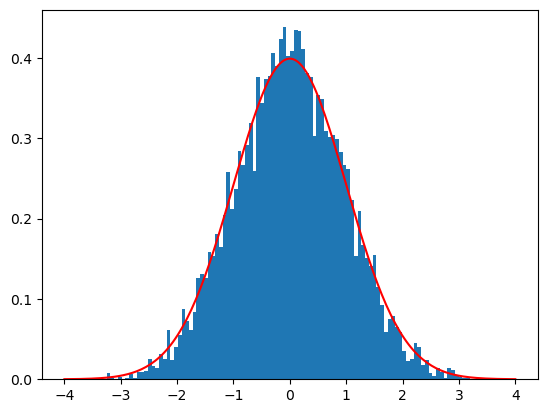

In [3]:
import matplotlib.pyplot as plt
plt.hist(samples.reshape(-1), bins=100, density=True);
def analytical_pdf(x):
    return (1.0 / jnp.sqrt(2 * jnp.pi)) * jnp.exp(-0.5 * x**2)
x = jnp.linspace(-4, 4, 200)
plt.plot(x, analytical_pdf(x), color='red', label='Analytical PDF')

In [4]:
@partial(jax.jit, static_argnums=(1,))
def mh_kernel(rng_key, prob_fn, prob_params, position, prob, step_size, PBC=10.0):
    key1, key2 = random.split(rng_key)
    proposal = position + random.uniform(
        key1, shape=position.shape, minval=-step_size, maxval=step_size
    )
    proposal = ((proposal + 0.5 * PBC) % PBC) - 0.5 * PBC
    proposal_prob = prob_fn(proposal, prob_params)
    accept_prob = jnp.minimum(1.0, proposal_prob / prob)
    accept = jax.random.uniform(key2) < accept_prob
    new_position = jnp.where(accept, proposal, position)
    new_prob = jnp.where(accept, proposal_prob, prob)
    acceptance_rate = jnp.mean(accept.astype(jnp.float32))
    return new_position, new_prob, acceptance_rate


@jax.jit
def adapt_step_size(step_size, accept, target=0.5, lr=0.01):
    return step_size


@partial(jax.jit, static_argnums=(1, 2, 3))
def mh_chain(rng_key, n_steps, PBC, prob_fn, prob_params, init_position, step_size=1.0):
    def body_fn(val, _):
        key, position, prob, step_size = val
        key, subkey = random.split(key)
        new_position, new_prob, acceptance_rate = mh_kernel(
            subkey, prob_fn, prob_params, position, prob, step_size=step_size, PBC=PBC
        )
        # step_size = adapt_step_size(step_size, acceptance_rate)
        _carry = (key, new_position, new_prob, step_size)
        return _carry, new_position

    init_prob = prob_fn(init_position, prob_params)
    init_val = (rng_key, init_position, init_prob, step_size)
    _, positions = jax.lax.scan(body_fn, init_val, None, length=n_steps)
    return positions

init_positions = jax.random.normal(random.PRNGKey(0), (1, DoF)) * 2.0
rng_key = random.PRNGKey(12345)
result = mh_chain(rng_key, 500_000, PBC, test_prob_fn, None, init_positions)
print("Single chain result shape:", result.shape)

Single chain result shape: (500000, 1, 1)


In [5]:
start = time.perf_counter()

result = mh_chain(rng_key, 500_000, PBC, test_prob_fn, None, init_positions)

end = time.perf_counter()
print("Single chain elapsed time:", end - start)
print("Single chain result shape:", result.shape)

Single chain elapsed time: 4.411258464999946
Single chain result shape: (500000, 1, 1)


In [7]:
with jax.profiler.trace("/tmp/jax_trace"):
    result = mh_chain(rng_key, 100, PBC, test_prob_fn, None, init_positions)


2025-12-10 12:22:54.693190: E external/xla/xla/python/profiler/internal/python_hooks.cc:416] Can't import tensorflow.python.profiler.trace
2025-12-10 12:22:57.979975: E external/xla/xla/python/profiler/internal/python_hooks.cc:416] Can't import tensorflow.python.profiler.trace


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/pfargas/software/anaconda3/envs/jax/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/home/pfargas/software/anaconda3/envs/jax/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 302, in dispatch_control
    await self.process_control(msg)
  File "/home/pfargas/software/anaconda3/envs/jax/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 308, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
                  ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/home/pfargas/software/anaconda3/envs/jax/lib/python3.13/site-packages/jupyter_client/session.py", line 994, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home

compilation ended
Simple MH elapsed time: 0.6292421309999554
Simple MH elapsed time: 0.6541892190002727
Simple MH elapsed time: 0.5900050019999981
Simple MH elapsed time: 0.5799266510002781
Simple MH elapsed time: 0.5763239419998172
Simple MH elapsed time: 0.5854524350002066
Simple MH elapsed time: 0.6040310690000297
Simple MH elapsed time: 0.6043155679999472
Simple MH elapsed time: 0.6433128029998443
Simple MH elapsed time: 0.6736974880000162
Simple MH elapsed time: 0.8046307820000038
Simple MH elapsed time: 0.8507107149998774
Simple MH elapsed time: 1.0643144499999835
Simple MH elapsed time: 1.3814784860001055
Simple MH elapsed time: 1.9989581170002566
MH elapsed time : 0.7960373470000377
MH elapsed time : 0.7916053760000068
MH elapsed time : 0.7911051909995876
MH elapsed time : 0.7834362300000066
MH elapsed time : 0.8047173059999295
MH elapsed time : 0.8552812689999882
MH elapsed time : 0.8429859439997927
MH elapsed time : 0.9382190719998107
MH elapsed time : 0.9410236270000496
MH e

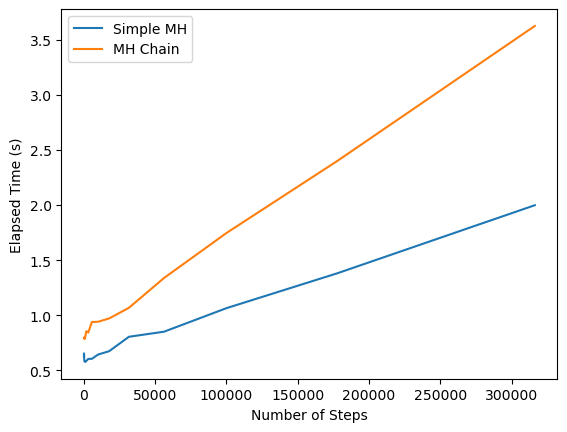

In [22]:
def gauss1d(x):
    return jnp.exp(-0.5 * jnp.sum((x) ** 2, axis=-1))

@partial(jax.jit, static_argnums=(0,))
def simple_mh_sample(n_steps, init_pos):
    rng_key = random.PRNGKey(0)
    x0 = init_pos.copy()
    def body_fn(i, val):
        rng_key, x0 = val
        rng_key, subkey = random.split(rng_key)
        xn = x0 + random.uniform(
            rng_key, shape=x0.shape, minval=-1.0, maxval=1.0
        )
        p_xn = gauss1d(xn)
        p_x0 = gauss1d(x0)
        accept_prob = jnp.minimum(1.0, p_xn / p_x0)
        accept = jax.random.uniform(rng_key) < accept_prob
        x0 = jnp.where(accept, xn, x0)
        return (subkey, x0)
    _, x0 = jax.lax.fori_loop(0, n_steps, body_fn, (rng_key, x0))
    return x0

@partial(jax.jit, static_argnums=(1,))
def mh_kernel(rng_key, prob_fn, prob_params, position, prob, step_size, PBC=10.0):
    key1, key2 = random.split(rng_key)
    proposal = position + random.uniform(
        key1, shape=position.shape, minval=-step_size, maxval=step_size
    )
    proposal = ((proposal + 0.5 * PBC) % PBC) - 0.5 * PBC
    proposal_prob = prob_fn(proposal, prob_params)
    accept_prob = jnp.minimum(1.0, proposal_prob / prob)
    accept = jax.random.uniform(key2) < accept_prob
    new_position = jnp.where(accept, proposal, position)
    new_prob = jnp.where(accept, proposal_prob, prob)
    acceptance_rate = jnp.mean(accept.astype(jnp.float32))
    return new_position, new_prob, acceptance_rate


@partial(jax.jit, static_argnums=(1, 2, 3))
def mh_chain(rng_key, n_steps, PBC, prob_fn, prob_params, init_position, step_size=1.0):
    def body_fn(val, _):
        key, position, prob, step_size = val
        key, subkey = random.split(key)
        new_position, new_prob, acceptance_rate = mh_kernel(
            subkey, prob_fn, prob_params, position, prob, step_size=step_size, PBC=PBC
        )
        # step_size = adapt_step_size(step_size, acceptance_rate)
        _carry = (key, new_position, new_prob, step_size)
        return _carry, new_position

    init_prob = prob_fn(init_position, prob_params)
    init_val = (rng_key, init_position, init_prob, step_size)
    _, positions = jax.lax.scan(body_fn, init_val, None, length=n_steps)
    return positions

start = time.perf_counter()
result = simple_mh_sample(1, jnp.array([0.0]))
end = time.perf_counter()

print("compilation ended")

init_position = jnp.array([0.0])

NSTEPS = 100_000

import numpy as np

times_simple_mh = []
times_mh_chain = []

n_steps_list = np.logspace(2, 5.5, num=15, dtype=int)

for n_steps in n_steps_list:
    start = time.perf_counter()
    result = simple_mh_sample(n_steps, init_position)
    end = time.perf_counter()
    print("Simple MH elapsed time:", end - start)
    times_simple_mh.append(end - start)

for n_steps in n_steps_list:
    start = time.perf_counter()
    result = mh_chain(rng_key, n_steps, PBC, test_prob_fn, None, init_position)
    end = time.perf_counter()
    print("MH elapsed time :", end - start)
    times_mh_chain.append(end - start)

import matplotlib.pyplot as plt
plt.plot(n_steps_list, times_simple_mh, label='Simple MH')
plt.plot(n_steps_list, times_mh_chain, label='MH Chain')
plt.xlabel('Number of Steps')
plt.ylabel('Elapsed Time (s)')
plt.legend()
plt.show()


In [25]:
import jax
import jax.numpy as jnp
from jax import random, lax

def gauss1d(x):
    return jnp.exp(-0.5 * jnp.sum(x**2))

@partial(jax.jit, static_argnums=(2,))
def chat_gpt_response(rng_key, init_pos, n_steps):

    def body_fn(carry, _):
        rng, x0 = carry
        rng, key1, key2 = random.split(rng, 3)

        # proposal
        xn = x0 + random.uniform(key1, shape=x0.shape, minval=-1.0, maxval=1.0)

        # MH accept
        accept = random.uniform(key2) < (
            gauss1d(xn) / gauss1d(x0)
        )
        x_new = jnp.where(accept, xn, x0)

        return (rng, x_new), x_new

    (_, xT), _ = lax.scan(body_fn, (rng_key, init_pos), None, length=n_steps)
    return xT

# warmup compilation
_ = chat_gpt_response(random.PRNGKey(0), jnp.array([0.0]), 10).block_until_ready()

times2 = []
for n in n_steps_list:
    _ = chat_gpt_response(random.PRNGKey(0), jnp.array([0.0]), n).block_until_ready()
    start = time.perf_counter()
    _ = chat_gpt_response(random.PRNGKey(0), jnp.array([0.0]), n).block_until_ready()
    end = time.perf_counter()
    times.append(end - start)

import matplotlib.pyplot as plt
plt.plot(n_steps_list, times, label='ChatGPT Response')
plt.plot(n_steps_list, times2, label='ChatGPT Response compiled')
plt.xlabel('Number of Steps')
plt.ylabel('Elapsed Time (s)')
plt.legend()
plt.show()

KeyboardInterrupt: 